# Input Generation — EV Availability and Driving Demand (50 kWh / 11 kW, 2026)

## Purpose

This notebook generates the **15-minute EV input time series** used in all archetype–DSO runs that include an electric vehicle (Archetypes 5, 7, 8): home availability ($f^t_{\mathrm{avail}}$) and driving-energy withdrawals ($E^t_{\mathrm{EV,dem}}$). These two series are **exogenous to the optimisation** — they define the opportunity window and the energy commitment that the scheduling layer must respect. The actual charging load is a decision variable and differs by strategy.

No external raw data file is required. The profile is generated deterministically from the stylised commuter pattern described in the thesis.

**Output files:**  
- `inputs/ev_profile_representative_50kwh_11kw_2026_15min.csv` — 15-min availability and driving demand  
- `inputs/ev_parameters_representative_50kwh_11kw_2026.csv` — frozen device parameters

## Driving pattern (stylised commuter)

| Period | Availability | Driving energy |
|---|---|---|
| Weekdays 00:00–08:00 | At home ($f_{avail}=1$) | 0 kWh |
| Weekdays 08:00–18:00 | Away ($f_{avail}=0$) | 5 kWh outbound (08:00–09:00), 5 kWh return (17:00–18:00) |
| Weekdays 18:00–24:00 | At home ($f_{avail}=1$) | 0 kWh |
| Weekends | At home all day ($f_{avail}=1$) | 0 kWh |

Daily driving energy on weekdays: **10 kWh/day** → annual driving energy: **~2,610 kWh/year**.

## Device parameter set

| Parameter | Symbol | Value | Notes |
|---|---|---|---|
| Usable battery capacity | $E_{\mathrm{EV,max}}$ | 50 kWh | Representative mid-sized BEV |
| Max. charging power | $P_{\mathrm{EV,max}}$ | 11 kW | Three-phase AC wallbox |
| Charging efficiency | $\eta_{\mathrm{EV,ch}}$ | 0.90 | 90% AC–DC |
| Standby losses | $q_{\mathrm{losses,EV}}$ | $10^{-4}$ h$^{-1}$ | 0.01 %/h |
| Departure minimum | $E_{\mathrm{min,dep}}$ | 25 kWh | 50% of capacity; mobility constraint |
| At-home minimum | $E_{\mathrm{min,ch}}$ | 10 kWh | 20% of capacity; avoids deep discharge |
| V2G | — | Not modelled | Charging only |

Parameter set inspired by Stute et al. (2024):
> Stute, J., et al. (2024). *Assessing conditions for economic household flexibility in Germany*. Applied Energy.

## Thesis reference

Chapter 3, Section 3.5.4 — *EV Wallbox Profile*; Chapter 4, Section 4.4.3 — *EV: SoC dynamics, availability, departure minimum*

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -- thesis figure rc (shared across notebooks) --
plt.rcParams.update({
    "axes.titlesize": 11,
    "axes.titleweight": "normal",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# ── Path configuration ─────────────────────────────────────────────────────────
def find_repo_root(marker='README.md'):
    p = Path(os.getcwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(f'Repo root not found (looked for: {marker})')

REPO_ROOT     = find_repo_root()
INPUTS        = REPO_ROOT / 'inputs'
INPUTS.mkdir(parents=True, exist_ok=True)

OUTPUT_PROFILE = INPUTS / 'ev_profile_representative_50kwh_11kw_2026_15min.csv'
OUTPUT_PARAMS  = INPUTS / 'ev_parameters_representative_50kwh_11kw_2026.csv'

# ── Device parameters ──────────────────────────────────────────────────────────
E_EV_MAX_KWH        = 50.0
P_EV_MAX_CH_KW      = 11.0
ETA_EV_CHARGE       = 0.90
Q_LOSSES_EV         = 1e-4        # 0.01 %/h
E_MIN_DEPARTURE_KWH = 0.50 * E_EV_MAX_KWH   # 25 kWh — mobility constraint
E_MIN_CHARGE_KWH    = 10.0                   # 20 % of max — avoids deep discharge

YEAR = 2026

print(f'Output profile : {OUTPUT_PROFILE.name}')
print(f'Output params  : {OUTPUT_PARAMS.name}')
print(f'E_EV_max       : {E_EV_MAX_KWH} kWh')
print(f'P_EV_max       : {P_EV_MAX_CH_KW} kW  |  η_ch: {ETA_EV_CHARGE}  |  q_loss: {Q_LOSSES_EV}/h')
print(f'E_min_dep      : {E_MIN_DEPARTURE_KWH} kWh  |  E_min_ch: {E_MIN_CHARGE_KWH} kWh')

Output profile : ev_profile_representative_50kwh_11kw_2026_15min.csv
Output params  : ev_parameters_representative_50kwh_11kw_2026.csv
E_EV_max       : 50.0 kWh
P_EV_max       : 11.0 kW  |  η_ch: 0.9  |  q_loss: 0.0001/h
E_min_dep      : 25.0 kWh  |  E_min_ch: 10.0 kWh


## Step 1 — Build availability and driving demand series

In [2]:
# 15-min index for 2026 in local time (CET/CEST), consistent with all other pipeline inputs.
idx = pd.date_range(
    start=f'{YEAR}-01-01', end=f'{YEAR}-12-31 23:45:00',
    freq='15min', tz='Europe/Paris'
)

hour    = idx.hour
weekday = idx.weekday          # 0 = Monday, 6 = Sunday
is_wd   = weekday < 5          # weekday flag

# ── Availability: 0 = away from home (cannot charge); 1 = at home
# Weekdays: away 08:00–18:00 (hours 8..17 inclusive)
f_avail = np.ones(len(idx), dtype=float)
f_avail[is_wd & (hour >= 8) & (hour <= 17)] = 0.0

# ── Driving-energy withdrawals: kWh per 15-min slot
# 10 kWh/day on weekdays: 5 kWh outbound (hour 8), 5 kWh return (hour 17)
# → 1.25 kWh per quarter-hour within those hours (5 kWh / 4 slots)
E_dem = np.zeros(len(idx))
E_dem[is_wd & (hour == 8)]  = 5.0 / 4   # outbound trip
E_dem[is_wd & (hour == 17)] = 5.0 / 4   # return trip

# ── Assemble and validate
ev = pd.DataFrame({'f_avail': f_avail, 'E_EV_demand_kWh': E_dem}, index=idx)
ev.index.name = 'local_time'

# Sanity: driving demand must be zero whenever f_avail = 1 (car not at home)
# (demand occurs only while away, so f_avail = 0 at those slots — this must always hold)
assert not ((ev['E_EV_demand_kWh'] > 0) & (ev['f_avail'] > 0)).any(), \
    'Profile inconsistency: driving demand > 0 while vehicle is at home'

annual_dem = ev['E_EV_demand_kWh'].sum()
assert 2595 <= annual_dem <= 2615, f'Annual driving energy out of range: {annual_dem:.0f} kWh'

print(f'15-min slots   : {len(ev):,}')
print(f'Slots away     : {(ev["f_avail"] == 0).sum():,}  ({(ev["f_avail"]==0).mean()*100:.1f}% of year)')
print(f'Annual driving : {annual_dem:.0f} kWh/year  ({annual_dem/10:.0f} weekdays × 10 kWh)')

15-min slots   : 35,040
Slots away     : 10,440  (29.8% of year)
Annual driving : 2610 kWh/year  (261 weekdays × 10 kWh)


## Step 2 — Visualisation

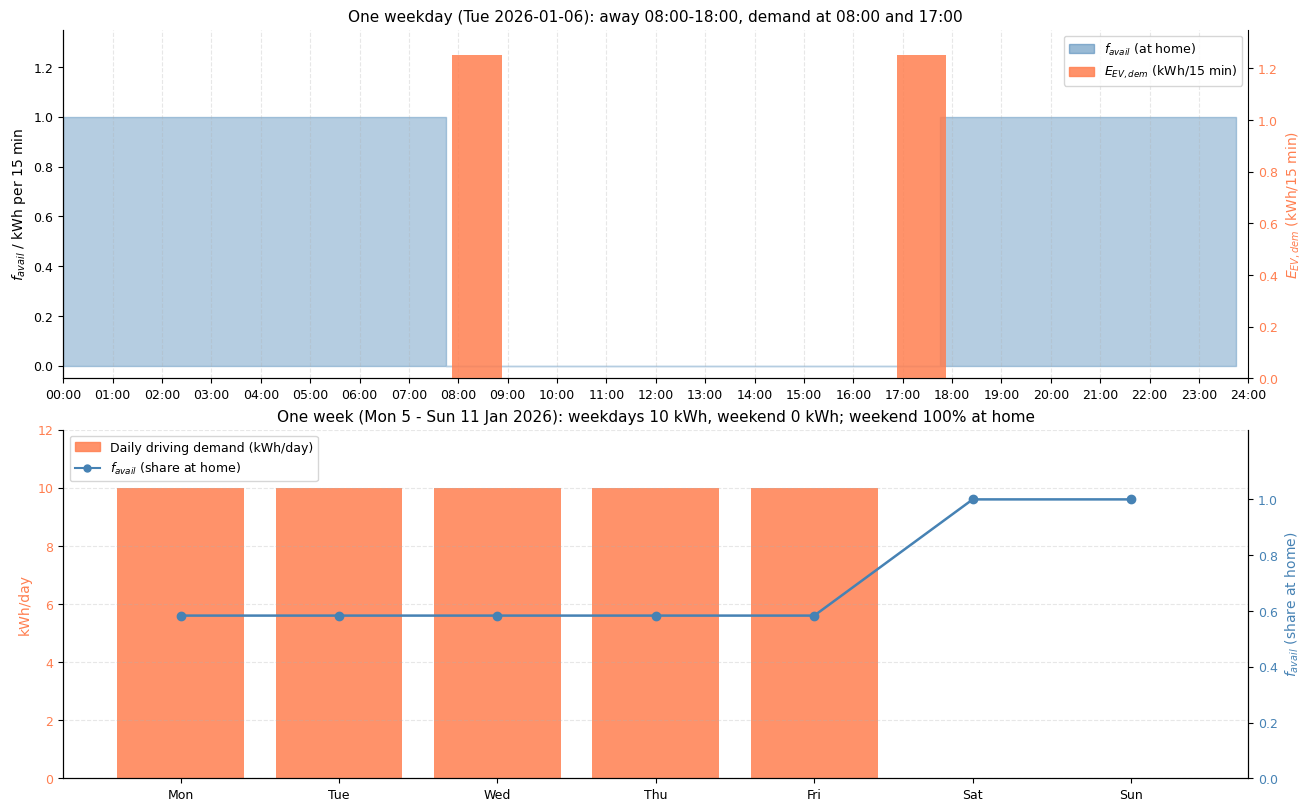

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)

day   = ev.loc['2026-01-06']
slots = np.arange(len(day))

ax0  = axes[0]
ax0b = ax0.twinx()

ax0.fill_between(slots, 0, day['f_avail'].values,
                 step='pre', alpha=0.40, color='steelblue')
ax0b.bar(slots, day['E_EV_demand_kWh'].values, width=1.0,
         color='coral', alpha=0.85)

ax0.set_xlim(0, 96)
ax0.set_ylim(-0.05, 1.35)
ax0.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
ax0.set_ylabel('$f_{avail}$ / kWh per 15 min')
ax0b.set_ylabel('$E_{EV,dem}$ (kWh/15 min)', color='coral')
ax0b.tick_params(axis='y', labelcolor='coral', labelsize=9)
ax0b.set_ylim(0, 1.35)

hour_ticks = list(range(0, 97, 4))
ax0.set_xticks(hour_ticks)
ax0.set_xticklabels([f'{h//4:02d}:00' for h in hour_ticks])
ax0.set_title('One weekday (Tue 2026-01-06): away 08:00-18:00, demand at 08:00 and 17:00')

handles_top = [
    mpatches.Patch(color='steelblue', alpha=0.55, label='$f_{avail}$ (at home)'),
    mpatches.Patch(color='coral',     alpha=0.85, label='$E_{EV,dem}$ (kWh/15 min)'),
]
ax0.legend(handles=handles_top, loc='upper right')
ax0.grid(axis='x', linestyle='--', alpha=0.3)
ax0.spines[['top', 'right']].set_visible(False)
ax0b.spines['top'].set_visible(False)

week      = ev.loc['2026-01-05':'2026-01-11 23:45']
daily_dem = week['E_EV_demand_kWh'].resample('D').sum()
daily_av  = week['f_avail'].resample('D').mean()

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
x = np.arange(7)

ax1  = axes[1]
ax1b = ax1.twinx()

ax1.bar(x, daily_dem.values, color='coral', alpha=0.85,
        label='Daily driving demand (kWh/day)')
ax1b.plot(x, daily_av.values, color='steelblue', lw=1.8,
          marker='o', markersize=6, label='$f_{avail}$ (share at home)')

ax1.set_xticks(x)
ax1.set_xticklabels(day_names)
ax1.set_ylabel('kWh/day', color='coral')
ax1.tick_params(axis='y', labelcolor='coral', labelsize=9)
ax1.set_ylim(0, 12)
ax1b.set_ylabel('$f_{avail}$ (share at home)', color='steelblue')
ax1b.tick_params(axis='y', labelcolor='steelblue', labelsize=9)
ax1b.set_ylim(0, 1.25)
ax1b.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

ax1.set_title(
    'One week (Mon 5 - Sun 11 Jan 2026): weekdays 10 kWh, weekend 0 kWh; weekend 100% at home',
)

handles_bot = [
    mpatches.Patch(color='coral',     alpha=0.85, label='Daily driving demand (kWh/day)'),
    mlines.Line2D([], [], color='steelblue', marker='o', markersize=5,
                  label='$f_{avail}$ (share at home)'),
]
ax1.legend(handles=handles_bot, loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.spines[['top']].set_visible(False)
ax1b.spines['top'].set_visible(False)

plt.show()


## Step 3 — Summary statistics

In [4]:
n_weekdays  = int(is_wd.sum() / 96)    # number of weekdays in 2026
n_weekends  = 365 - n_weekdays
slots_away  = int((ev['f_avail'] == 0).sum())
slots_home  = len(ev) - slots_away

print('EV Profile — Summary (2026)')
print('-' * 50)
print(f'  Weekdays in 2026        : {n_weekdays}')
print(f'  Weekend days            : {n_weekends}')
print(f'  Slots at home           : {slots_home:,}  ({slots_home/len(ev)*100:.1f}%)')
print(f'  Slots away              : {slots_away:,}  ({slots_away/len(ev)*100:.1f}%)')
print(f'  Annual driving demand   : {ev["E_EV_demand_kWh"].sum():.0f} kWh')
print(f'  Peak driving slot       : {ev["E_EV_demand_kWh"].max():.2f} kWh/15 min  (= {ev["E_EV_demand_kWh"].max()/0.25:.1f} kW equiv.)')
print()
print('Device parameters')
print('-' * 50)
print(f'  E_EV_max                : {E_EV_MAX_KWH} kWh')
print(f'  P_EV_max_ch             : {P_EV_MAX_CH_KW} kW')
print(f'  η_EV_charge             : {ETA_EV_CHARGE}')
print(f'  q_losses_EV             : {Q_LOSSES_EV}/h  ({Q_LOSSES_EV*100:.2f} %/h)')
print(f'  E_min_departure         : {E_MIN_DEPARTURE_KWH} kWh  (50% of max)')
print(f'  E_min_charge            : {E_MIN_CHARGE_KWH} kWh  (20% of max)')
print('-' * 50)

EV Profile — Summary (2026)
--------------------------------------------------
  Weekdays in 2026        : 261
  Weekend days            : 104
  Slots at home           : 24,600  (70.2%)
  Slots away              : 10,440  (29.8%)
  Annual driving demand   : 2610 kWh
  Peak driving slot       : 1.25 kWh/15 min  (= 5.0 kW equiv.)

Device parameters
--------------------------------------------------
  E_EV_max                : 50.0 kWh
  P_EV_max_ch             : 11.0 kW
  η_EV_charge             : 0.9
  q_losses_EV             : 0.0001/h  (0.01 %/h)
  E_min_departure         : 25.0 kWh  (50% of max)
  E_min_charge            : 10.0 kWh  (20% of max)
--------------------------------------------------


## Step 4 — Export to CSV

In [5]:
# ── 4a. 15-min profile: strip timezone, keep wall-clock timestamps ──────────────
df_out = ev.reset_index()
df_out['local_time'] = pd.to_datetime(df_out['local_time']).dt.tz_localize(None)
df_out['local_time'] = df_out['local_time'].dt.strftime('%Y-%m-%d %H:%M:%S')

df_out.to_csv(OUTPUT_PROFILE, index=False)
print(f'Exported profile : {OUTPUT_PROFILE.name}  ({len(df_out):,} rows)')
print(df_out.head(6).to_string(index=False))

# ── 4b. Frozen device parameter table ──────────────────────────────────────────
params = [
    ('E_EV_max_kWh',        E_EV_MAX_KWH,        'usable battery capacity'),
    ('P_EV_max_ch_kW',      P_EV_MAX_CH_KW,      '11 kW three-phase AC wallbox'),
    ('eta_EV_charge',       ETA_EV_CHARGE,       'AC–DC charging efficiency'),
    ('q_losses_EV',         Q_LOSSES_EV,         '0.01 %/h standby losses'),
    ('E_min_departure_kWh', E_MIN_DEPARTURE_KWH, '50% of max; mobility constraint'),
    ('E_min_charge_kWh',    E_MIN_CHARGE_KWH,    '20% of max; avoids deep discharge'),
    ('year_export',         YEAR,                'CSV datetime alignment'),
    ('driving_kWh_per_weekday', 10.0,            'outbound 5 kWh + return 5 kWh'),
    ('annual_driving_kWh',  float(ev['E_EV_demand_kWh'].sum()), 'computed from profile'),
    ('n_weekdays_2026',     n_weekdays,          'calendar year 2026'),
]

df_params = pd.DataFrame(params, columns=['parameter', 'value', 'notes'])
df_params.to_csv(OUTPUT_PARAMS, index=False)
print(f'\nExported params  : {OUTPUT_PARAMS.name}  ({len(df_params)} rows)')

Exported profile : ev_profile_representative_50kwh_11kw_2026_15min.csv  (35,040 rows)
         local_time  f_avail  E_EV_demand_kWh
2026-01-01 00:00:00      1.0              0.0
2026-01-01 00:15:00      1.0              0.0
2026-01-01 00:30:00      1.0              0.0
2026-01-01 00:45:00      1.0              0.0
2026-01-01 01:00:00      1.0              0.0
2026-01-01 01:15:00      1.0              0.0

Exported params  : ev_parameters_representative_50kwh_11kw_2026.csv  (10 rows)
